In [8]:
import sys
sys.path.append('../src')

from digital_twin import FleetDigitalTwin
from simulator import CMAPSSSimulator

# Initialize
fleet = FleetDigitalTwin()
simulator = CMAPSSSimulator()
print("Initialized successfully!")

Fleet Digital Twin initialized with config: {'input_size': 14, 'hidden_size': 64, 'num_layers': 2, 'window_size': 30}
Simulator loaded: 100 engines, 14 features
Initialized successfully!


In [9]:
sample_engines = simulator.get_sample_engines(n=5)

# More aggressive stages to get mixed statuses
life_stages = [0.3, 0.55, 0.75, 0.88, 0.95]

for engine_id, stage in zip(sample_engines, life_stages):
    fleet.add_engine(engine_id)
    all_data = simulator.get_engine_data(engine_id)
    cutoff = int(len(all_data) * stage)
    for sensor_data in all_data[:cutoff]:
        state = fleet.ingest(engine_id, sensor_data)

print("Simulation complete!")
summary = fleet.get_fleet_summary()
for key, val in summary.items():
    print(f"   {key}: {val}")

c:\Users\ASUS\Documents\Tata\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\ASUS\Documents\Tata\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\ASUS\Documents\Tata\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\ASUS\Documents\Tata\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\ASUS\Documents\Tata\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.w

Simulation complete!
   total_engines: 5
   healthy: 2
   caution: 1
   critical: 1
   initializing: 0


c:\Users\ASUS\Documents\Tata\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\ASUS\Documents\Tata\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\ASUS\Documents\Tata\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\ASUS\Documents\Tata\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\ASUS\Documents\Tata\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.w

In [11]:
# Show fleet status
print("Fleet Status (sorted by RUL):\n")
for engine in fleet.get_fleet_status():
    print(f"Engine {engine['engine_id']:3d} | "
          f"Status: {engine['status']:12s} | "
          f"RUL: {str(engine['current_rul']):6s} cycles | "
          f"Health: {engine['health_score']}%")

Fleet Status (sorted by RUL):

Engine   5 | Status: CRITICAL     | RUL: 8.96   cycles | Health: 7.17%
Engine   4 | Status: WARNING      | RUL: 20.8   cycles | Health: 16.64%
Engine   3 | Status: CAUTION      | RUL: 46.85  cycles | Health: 37.48%
Engine   2 | Status: HEALTHY      | RUL: 108.46 cycles | Health: 86.77%
Engine   1 | Status: HEALTHY      | RUL: 109.23 cycles | Health: 87.38%


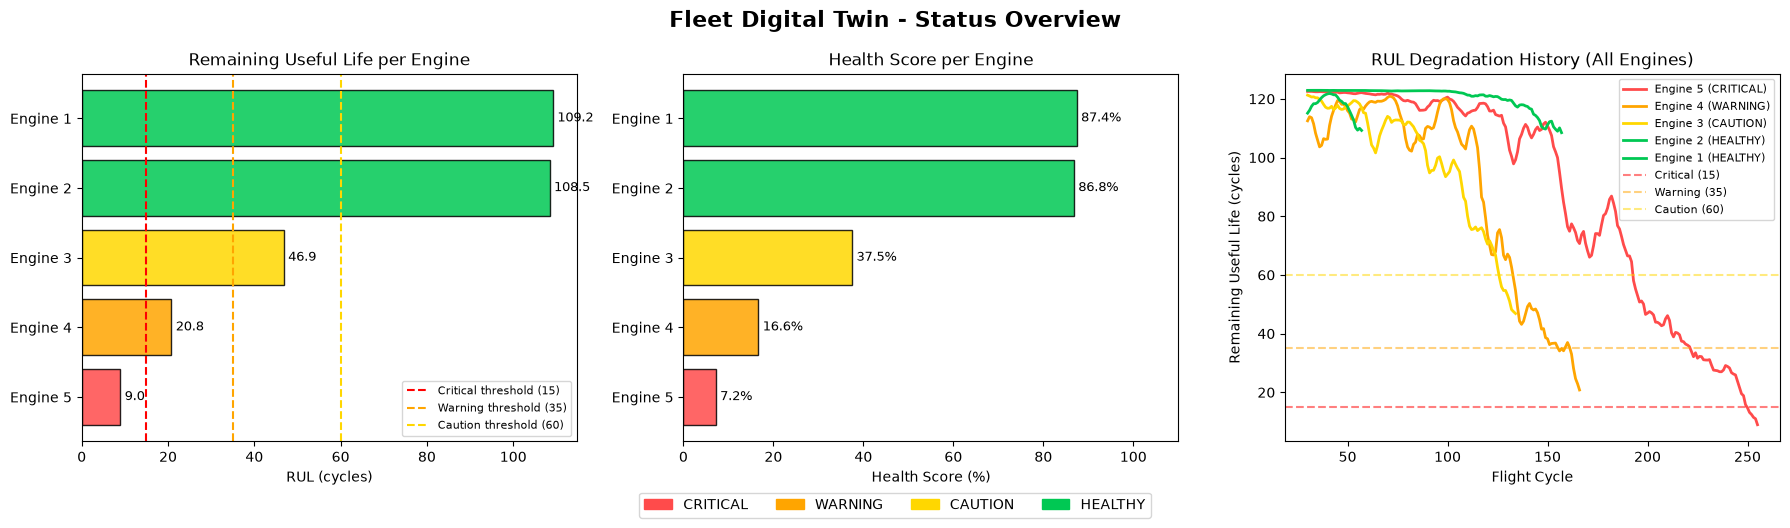

Fleet visualization saved to docs/


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fleet_status = fleet.get_fleet_status()

engine_ids   = [f"Engine {e['engine_id']}" for e in fleet_status]
rul_values   = [e['current_rul'] for e in fleet_status]
health_values= [e['health_score'] for e in fleet_status]
statuses     = [e['status'] for e in fleet_status]

# Color map
color_map = {
    'CRITICAL': '#ff4b4b',
    'WARNING' : '#ffa500',
    'CAUTION' : '#ffd700',
    'HEALTHY' : '#00c853'
}
colors = [color_map[s] for s in statuses]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Fleet Digital Twin - Status Overview', fontsize=16, fontweight='bold')

# Plot 1 - RUL Bar Chart
bars = axes[0].barh(engine_ids, rul_values, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Remaining Useful Life per Engine')
axes[0].set_xlabel('RUL (cycles)')
axes[0].axvline(x=15, color='red',    linestyle='--', label='Critical threshold (15)')
axes[0].axvline(x=35, color='orange', linestyle='--', label='Warning threshold (35)')
axes[0].axvline(x=60, color='gold',   linestyle='--', label='Caution threshold (60)')
axes[0].legend(fontsize=8)
for bar, val in zip(bars, rul_values):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=9)

# Plot 2 - Health Score Bar Chart
bars2 = axes[1].barh(engine_ids, health_values, color=colors, edgecolor='black', alpha=0.85)
axes[1].set_title('Health Score per Engine')
axes[1].set_xlabel('Health Score (%)')
axes[1].set_xlim(0, 110)
for bar, val in zip(bars2, health_values):
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)

# Plot 3 - RUL Degradation History
axes[2].set_title('RUL Degradation History (All Engines)')
axes[2].set_xlabel('Flight Cycle')
axes[2].set_ylabel('Remaining Useful Life (cycles)')

for engine in fleet_status:
    twin    = fleet.engines[engine['engine_id']]
    history = twin.rul_history
    if history:
        cycles = [h['cycle'] for h in history]
        ruls   = [h['rul']   for h in history]
        color  = color_map[engine['status']]
        axes[2].plot(cycles, ruls,
                     label=f"Engine {engine['engine_id']} ({engine['status']})",
                     color=color, linewidth=2)

axes[2].axhline(y=15, color='red',    linestyle='--', alpha=0.5, label='Critical (15)')
axes[2].axhline(y=35, color='orange', linestyle='--', alpha=0.5, label='Warning (35)')
axes[2].axhline(y=60, color='gold',   linestyle='--', alpha=0.5, label='Caution (60)')
axes[2].legend(fontsize=8)

# Legend patches
patches = [mpatches.Patch(color=v, label=k) for k, v in color_map.items()]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig('../docs/digital_twin_fleet.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fleet visualization saved to docs/")

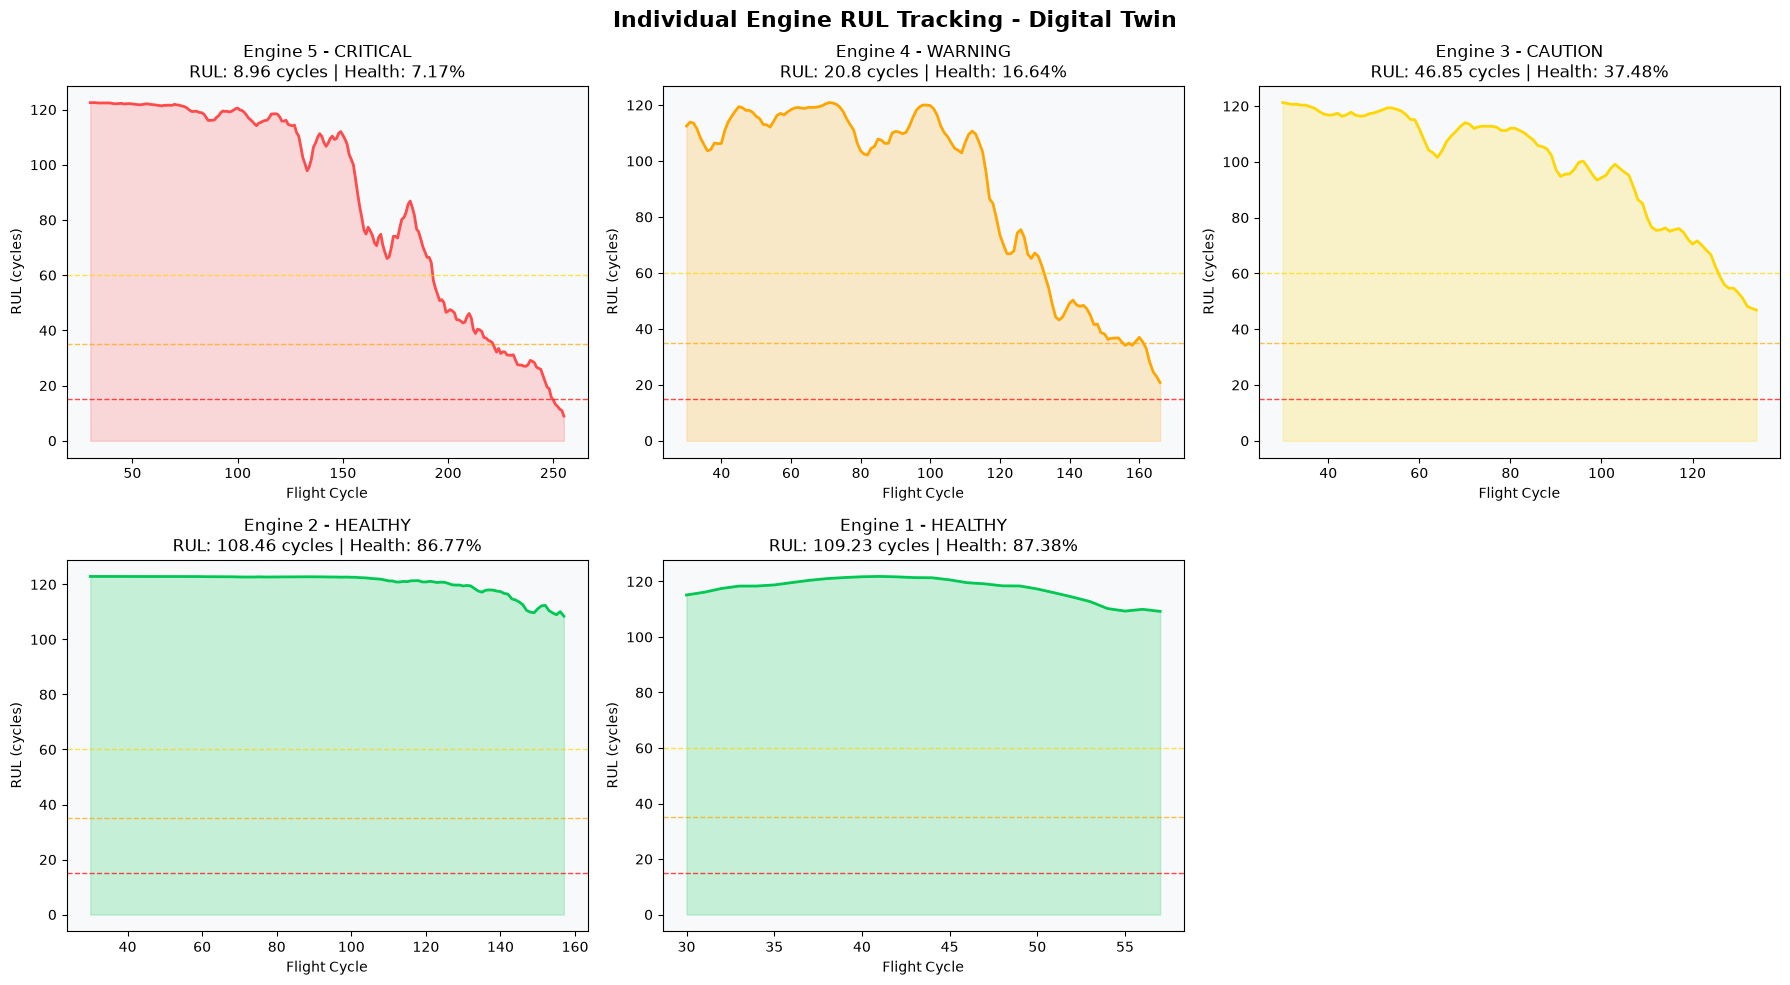

Engine RUL tracking saved to docs/


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Individual Engine RUL Tracking - Digital Twin', fontsize=16, fontweight='bold')
axes = axes.flatten()

for idx, engine in enumerate(fleet_status):
    twin    = fleet.engines[engine['engine_id']]
    history = twin.rul_history
    color   = color_map[engine['status']]

    if history:
        cycles = [h['cycle'] for h in history]
        ruls   = [h['rul']   for h in history]

        axes[idx].plot(cycles, ruls, color=color, linewidth=2)
        axes[idx].fill_between(cycles, ruls, alpha=0.2, color=color)
        axes[idx].axhline(y=15, color='red',    linestyle='--', alpha=0.7, linewidth=1)
        axes[idx].axhline(y=35, color='orange', linestyle='--', alpha=0.7, linewidth=1)
        axes[idx].axhline(y=60, color='gold',   linestyle='--', alpha=0.7, linewidth=1)
        axes[idx].set_title(f"Engine {engine['engine_id']} - {engine['status']}\n"
                            f"RUL: {engine['current_rul']} cycles | "
                            f"Health: {engine['health_score']}%")
        axes[idx].set_xlabel('Flight Cycle')
        axes[idx].set_ylabel('RUL (cycles)')
        axes[idx].set_facecolor('#f8f9fa')

# Hide last empty subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig('../docs/engine_rul_tracking.png', dpi=150, bbox_inches='tight')
plt.show()
print("Engine RUL tracking saved to docs/")